In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import io
import time
import cv2
from robot_client import RobotClient, OscListener

State definition:[xours, yours, orientationours, velours, red_x, red_y, vel_red, green_x, green_y, vel_green ]
vel is computed previous time step
Action Defintion: [left rotor, right rotor, 0.5] all combinations discretized to increments of 1, 0:50 
Reward definition: [] if close to goal robot = 10, if close to red robot = 

Transition function:


In [ ]:
def make_action(duration = 0.5):
    actions = []
    for i in range(51):
        for j in range(51):
            action = [i, j, duration]
            actions.append(action)
    return actions
        


In [ ]:
# create an MLP to embedd the state variable?

In [ ]:
# state set up

CELL_SIZE_CM = 1  # real-world cm per grid cell

height = 240
width = 180

N_COLS = width   # discrete x states, x in [0, width)
N_ROWS = height  # discrete y states, y in [0, height)

ORIENTATIONS = {0: "N", 1: "E", 2: "S", 3: "W"}
ORIENTATION_TO_IDX = {name: idx for idx, name in ORIENTATIONS.items()}
N_ORIENTATIONS = len(ORIENTATIONS)


def in_bounds(x, y):
    return 0 <= x < N_COLS and 0 <= y < N_ROWS


def get_position(state):
    """Convert a flat state index into (x, y, orientation).
    Origin (0, 0) is the top-left corner; y increases downward.
    State indices run row-major over (x, y), with orientation as the
    fastest-varying component: state = (y * N_COLS + x) * N_ORIENTATIONS + orientation_idx
    """
    total_states = N_COLS * N_ROWS * N_ORIENTATIONS
    if not (0 <= state < total_states):
        raise ValueError(f"state {state} is out of bounds for a {N_COLS}x{N_ROWS}x{N_ORIENTATIONS} state space")
    o_idx = state % N_ORIENTATIONS
    grid_idx = state // N_ORIENTATIONS
    x = grid_idx % N_COLS
    y = grid_idx // N_COLS
    return x, y, ORIENTATIONS[o_idx]


def get_state(x, y, orientation):
    """Expanded to fit the new state space definition that includes positions of 3 robots. Convert (x, y, orientation) 
    of all robots, into a flat state index. Include velocities of 3 robots as well."""
    """orientation: 'N'/'E'/'S'/'W' or its index 0-3."""
    o_idx = orientation if isinstance(orientation, int) else ORIENTATION_TO_IDX[orientation]
    return (y * N_COLS + x) * N_ORIENTATIONS + o_idx



########################################################################################################
# add position of red and green robots to expand definition of state space to include positions of both robots



In [ ]:
# auxillary robots dimensions, in cm red and green:

front_bumper = 27
back_bumper = 12
length_along_spine = 22


In [3]:
# heading-relative action space, shared by every robot (preprogrammed or learned)
ACTIONS = {0: "stay", 1: "forward", 2: "turn_left", 3: "turn_right"}

# forward displacement by current orientation index (N, E, S, W)
MOTOR_STEP_CM = 5  # measured real-world displacement of one 'forward' action
STEP_SIZE = max(1, round(MOTOR_STEP_CM / CELL_SIZE_CM))  # displacement in grid cells

# forward displacement by current orientation index (N, E, S, W)
FORWARD_DELTA = {0: (0, -STEP_SIZE), 1: (STEP_SIZE, 0), 2: (0, STEP_SIZE), 3: (-STEP_SIZE, 0)}

In [5]:

def reward(state, goal_states, step_cost=-1, goal_reward=10):
    """Reward for being in `state`. Depends only on reaching the goal region:
    a fixed cost per timestep, plus a bonus once inside the goal region.
    """
    x, y, _ = get_position(state)
    goal_xy = {get_position(s)[:2] for s in goal_states}
    return goal_reward if (x, y) in goal_xy else step_cost

In [8]:
# arena corners in raw camera pixel coordinates (calibrated once, camera isn't axis-aligned with the arena)
ARENA_CORNERS_PX = np.array([
    [1217, 400],  # top left
    [157, 890],   # top right
    [1159, 71],   # bottom left
    [179, 172],   # bottom right
], dtype=np.float32)

# corresponding corners in our state-space coordinate frame
ARENA_CORNERS_STATE = np.array([
    [0, 0],
    [N_COLS - 1, 0],
    [0, N_ROWS - 1],
    [N_COLS - 1, N_ROWS - 1],
], dtype=np.float32)

_ARENA_HOMOGRAPHY = cv2.getPerspectiveTransform(ARENA_CORNERS_PX, ARENA_CORNERS_STATE)
_ARENA_HOMOGRAPHY_INV = cv2.getPerspectiveTransform(ARENA_CORNERS_STATE, ARENA_CORNERS_PX)


def pixel_to_arena(px, py):
    """Map a raw camera pixel coordinate to (x, y) in the state-space coordinate frame."""
    pt = np.array([[[px, py]]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(pt, _ARENA_HOMOGRAPHY)
    return float(mapped[0, 0, 0]), float(mapped[0, 0, 1])


def arena_to_pixel(x, y):
    """Map a state-space (x, y) coordinate back to raw camera pixel coordinates
    (the inverse of pixel_to_arena), e.g. for overlaying the goal region on the
    live camera frame.
    """
    pt = np.array([[[x, y]]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(pt, _ARENA_HOMOGRAPHY_INV)
    return float(mapped[0, 0, 0]), float(mapped[0, 0, 1])


def goal_states_to_pixels(goal_states):
    """Project each goal state's (x, y) cell into camera pixel coordinates."""
    return [arena_to_pixel(x, y) for x, y in {get_position(s)[:2] for s in goal_states}]


def vector_to_orientation(dx, dy):
    """Snap a direction vector to the nearest cardinal orientation used by our state space."""
    if abs(dx) >= abs(dy):
        return "E" if dx > 0 else "W"
    return "S" if dy > 0 else "N"


def has_invalid_marker(robot_data):
    """Bonsai sends -1 for any marker (red/green) it couldn't detect in the current frame."""
    return any(v == -1 for v in robot_data)


def robot_to_state(robot_data):
    """Convert the robot's two-marker camera readout into a discrete state.
    robot_data: [x_red, y_red, x_green, y_green] in raw camera pixel coordinates.
    Red is mounted on the front of the robot, green on the back; the vector
    from green -> red gives its heading.
    """
    x_red_px, y_red_px, x_green_px, y_green_px = robot_data

    x_red, y_red = pixel_to_arena(x_red_px, y_red_px)
    x_green, y_green = pixel_to_arena(x_green_px, y_green_px)

    orientation = vector_to_orientation(x_red - x_green, y_red - y_green)

    x = min(max(round(x_red), 0), N_COLS - 1)
    y = min(max(round(y_red), 0), N_ROWS - 1)
    return get_state(x, y, orientation)


def show_preview(robot, robot_data, goal_states, window_name="Preview"):
    """Overlay the tracked red/green markers and the goal region on the live
    camera frame, so you can visually confirm the robot is in frame and being
    tracked correctly before driving it.
    """
    frame = robot.frame
    if frame is None:
        return
    vis = frame.copy()
    for gx, gy in goal_states_to_pixels(goal_states):
        cv2.circle(vis, (int(gx), int(gy)), 2, (0, 255, 0), -1)
    if has_invalid_marker(robot_data):
        cv2.putText(vis, "marker not detected", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:
        x_red, y_red, x_green, y_green = robot_data
        cv2.circle(vis, (int(x_red), int(y_red)), 6, (0, 0, 255), -1)
        cv2.circle(vis, (int(x_green), int(y_green)), 6, (0, 200, 0), -1)
    cv2.imshow(window_name, vis)
    cv2.waitKey(1)

In [9]:
def action_to_motor(action):
    """Convert a heading-relative action (stay, forward, turn_left, turn_right)
    into a motor command for the robot. (left wheel, right wheel, duration)
    """
    if action == 0:  # stay
        return np.array([0, 0, 1]) # third variable is for the duration of the stay
    elif action == 1:  # forward
        return np.array([30, 30, 0.5]) # forward half a second 
    elif action == 2:  # turn_left
        return np.array([0, 44, 1])
    elif action == 3:  # turn_right
        return np.array([44, 0, 1])
    else:
        raise ValueError(f"Unknown action {action}")


In [10]:
# aux = [red_x, red_y, green_x, green_y] 


[OscListener:9000] got /auxrobots [1207, 472, 414, 499]

[OscListener:9000] got /robot [378, 502, 414, 499]

[OscListener:9000] got /auxrobots [1209, 434, 414, 499]

[OscListener:9000] got /robot [378, 502, 414, 499]

[OscListener:9000] got /auxrobots [1207, 472, 414, 498]State: 72637, Position: (159, 100), Action: turn_left, Wheels: (L=0, R=44), Duration: 1s


[OscListener:9000] got /robot [379, 502, 414, 498]

[OscListener:9000] got /auxrobots [1208, 450, 414, 499]

[OscListener:9000] got /robot [378, 502, 414, 499]

[OscListener:9000] got /auxrobots [1207, 467, 414, 499]

[OscListener:9000] got /robot [379, 502, 414, 499]

[OscListener:9000] got /auxrobots [1208, 465, 414, 499]

[OscListener:9000] got /robot [378, 502, 414, 499]

[OscListener:9000] got /auxrobots [1207, 480, 414, 498]

[OscListener:9000] got /robot [378, 502, 414, 498]

[OscListener:9000] got /auxrobots [1208, 466, 413, 498]

[OscListener:9000] got /robot [377, 502, 413, 498]

[OscListener:9000] got /auxrobots [120

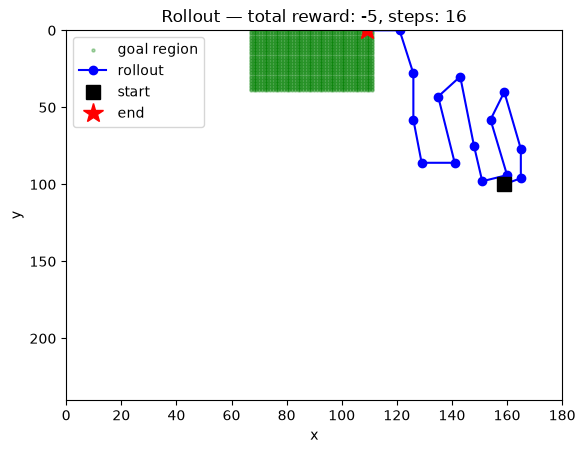

In [ ]:


def run_policy(start_state, policy, goal_states, max_steps=500, simulation=False, position_timeout=5.0, settle_time=0.2):
    """Roll out `policy` from `start_state` until it reaches the goal region or max_steps.
    When simulation=False, the next state (and the initial state) is read from
    Bonsai's /robot OSC feed (port 9000) instead of the hand-coded transition()
    model and the passed-in start_state — we don't actually know where the robot
    is until we hear from Bonsai, so start_state is only used in simulation mode.
    /robot sends [x_red, y_red, x_green, y_green] — raw camera pixel coordinates
    of the two markers on the robot. See robot_to_state() for how this is converted.

    On real hardware:
    - Before driving, shows a live preview window with the tracked markers and
      goal region overlaid, and blocks on an Enter-to-start prompt so you can
      confirm tracking looks right first.
    - Each step: drive for `duration`, stop the wheels, wait `settle_time` for
      the tracker to catch up, then read the now-stationary position. If a
      marker read comes back invalid (-1, meaning Bonsai lost track of it that
      frame), the state update for that step is skipped and the previous state
      is kept instead of computing garbage from -1 pixel coordinates.
    """
    goal_xy = {get_position(s)[:2] for s in goal_states}

    robot = RobotClient()
    robot.start()

    robot_data = [0, 0, 0, 0]  # [x_red, y_red, x_green, y_green] (raw camera pixels)
    got_position = False

    def on_robot(args):
        nonlocal got_position
        robot_data[:] = args
        got_position = True

    positions = None
    if not simulation:
        positions = OscListener(port=9000)
        positions.subscribe("/robot", on_robot)
        positions.start()

        waited = 0.0
        while not got_position and waited < position_timeout:
            time.sleep(0.1)
            waited += 0.1
        if not got_position:
            robot.stop()
            raise RuntimeError(f"Timed out after {position_timeout}s waiting for initial /robot position from Bonsai")

      
        if has_invalid_marker(robot_data):
            robot.stop()
            raise RuntimeError("Marker not detected at start — check camera/tracking before running.")
        state = robot_to_state(robot_data)
    else:
        state = start_state

    history = [get_position(state)[:2]]
    rewards = []

    for _ in range(max_steps):
        r = reward(state, goal_states)
        rewards.append(r)
        x, y, _ = get_position(state)
        if (x, y) in goal_xy:
            break
        action = policy[state]
        left, right, duration = action_to_motor(action)
        robot.set_wheels(left, right)  # drive
        print(f"State: {state}, Position: ({x}, {y}), Action: {ACTIONS[action]}, Wheels: (L={left}, R={right}), Duration: {duration}s")
        time.sleep(duration) # pauses 
        if simulation:
            state = transition(state, action)
        else:
            robot.set_wheels(0, 0)   # stop moving before reading position
            # time.sleep(settle_time)  # let the tracker catch up to the now-stationary robot
            if has_invalid_marker(robot_data):
                print("Warning: marker not detected this step, keeping previous state.")
            else:
                state = robot_to_state(robot_data)
        history.append(get_position(state)[:2])

    print("Goal reached!" if rewards[-1] > 0 else "Max steps reached without reaching goal.")
    robot.set_wheels(0, 0)
    robot.stop()
    if positions is not None:
        positions.stop()
    return history, rewards


start_state = get_state(x=160, y=200, orientation="N")

trajectory, rewards = run_policy(start_state, test_policy, upper_center_states, simulation=False)
xs, ys = zip(*trajectory)

fig, ax = plt.subplots()
for x, y in {get_position(s)[:2] for s in upper_center_states}:
    ax.scatter(x, y, color="green", s=5, alpha=0.3, label="goal region" if (x, y) == next(iter({get_position(s)[:2] for s in upper_center_states})) else None)
ax.plot(xs, ys, "o-", color="blue", label="rollout")
ax.plot(xs[0], ys[0], "s", color="black", markersize=10, label="start")
ax.plot(xs[-1], ys[-1], "*", color="red", markersize=15, label="end")
ax.set_xlim(0, N_COLS)
ax.set_ylim(N_ROWS, 0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Rollout — total reward: {sum(rewards)}, steps: {len(rewards)}")
ax.legend()
plt.show()
